In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Dataset Breast Cancer: 569 sample, 30 fitur, 2 kelas.
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# SVM wajib pakai scaling karena sensitif terhadap perbedaan skala fitur.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit di data latih
X_test = scaler.transform(X_test)        # transform saja di data uji (jangan fit lagi!)

# Dua model SVM dengan kernel berbeda.
models = {
    "SVM Linear": SVC(kernel="linear", C=1),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n{name} accuracy:", round(accuracy_score(y_test, pred), 3))
    print(classification_report(y_test, pred, target_names=data.target_names))


SVM Linear accuracy: 0.956
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


SVM RBF accuracy: 0.982
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



##Support Vector Machine (SVM) pada Dataset Iris
#Tujuan
Tujuan dari praktikum ini adalah untuk memahami cara menggunakan algoritma Support Vector Machine (SVM) untuk melakukan klasifikasi data. Selain itu praktikum ini juga bertujuan untuk membandingkan penggunaan kernel Linear dan RBF, serta melihat pengaruh parameter C dan Gamma terhadap performa model.

#Langkah Kerja
1. Mengimpor library yang dibutuhkan untuk analisis data.
2. Memuat dataset Iris dari Scikit-Learn.
3. Membagi data menjadi data training dan data testing.
4. Melakukan proses scaling data menggunakan StandardScaler.
5. Membuat model SVM dengan kernel Linear dan RBF.
6. Membandingkan performa model menggunakan confusion matrix dan akurasi.
7. Melakukan tuning parameter C dan Gamma untuk melihat perubahan performa model.
8. Menampilkan hasil evaluasi dan membuat kesimpulan.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

Pada bagian ini saya mengimpor beberapa library yang akan digunakan dalam program. Library pandas digunakan untuk pengolahan data, matplotlib dan seaborn digunakan untuk membuat visualisasi grafik, sedangkan library dari Scikit-Learn digunakan untuk memuat dataset, membagi data, melakukan scaling, membuat model SVM, dan menghitung akurasi model.

In [2]:
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)

Pada bagian ini dataset Iris dimuat menggunakan fungsi load_iris(). Dataset tersebut kemudian dibagi menjadi data training dan data testing menggunakan train_test_split(). Sebanyak 80% data digunakan untuk pelatihan model, sedangkan 20% data digunakan untuk pengujian model.

Output dari bagian ini adalah terbentuknya data X_train, X_test, y_train, dan y_test yang akan digunakan untuk proses pelatihan dan pengujian model.

In [4]:
# SCALING
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Pada bagian ini dilakukan proses scaling data menggunakan StandardScaler. Scaling dilakukan karena algoritma SVM sangat sensitif terhadap perbedaan skala fitur. Dengan melakukan scaling, semua fitur memiliki skala yang seimbang sehingga model dapat bekerja dengan lebih baik.

--- TUGAS 1: PERBANDINGAN KERNEL ---


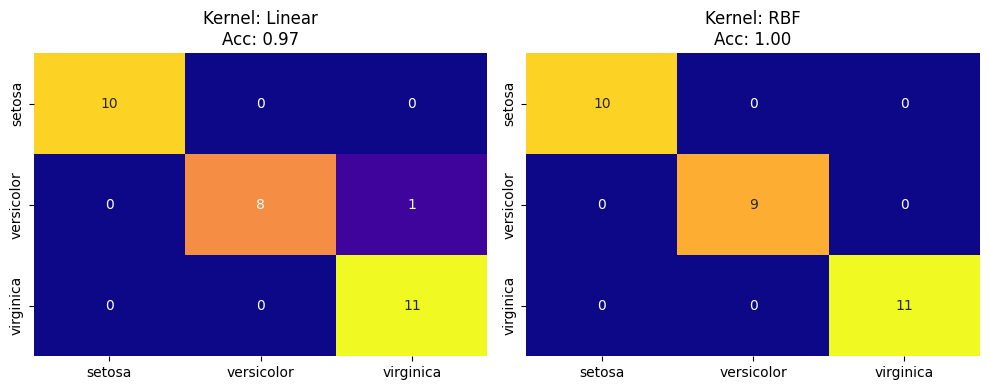

In [5]:
# TUGAS 1: BANDINGKAN KERNEL LINEAR VS RBF

print("--- TUGAS 1: PERBANDINGAN KERNEL ---")
models = {
    "Linear": SVC(kernel="linear", C=1),
    "RBF": SVC(kernel="rbf", C=1, gamma="auto")
}

plt.figure(figsize=(10, 4))
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    plt.subplot(1, 2, i+1)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, cmap='plasma', cbar=False,
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.title(f"Kernel: {name}\nAcc: {accuracy_score(y_test, y_pred):.2f}")

plt.tight_layout()
plt.show()

Pada bagian ini saya membandingkan dua jenis kernel pada SVM, yaitu Linear dan RBF. Model dilatih menggunakan data training kemudian digunakan untuk memprediksi data testing. Hasil prediksi kemudian ditampilkan menggunakan confusion matrix agar lebih mudah melihat performa klasifikasi dari setiap model.

Output yang dihasilkan berupa dua grafik confusion matrix yang menunjukkan hasil klasifikasi dari kernel Linear dan RBF. Pada grafik tersebut juga ditampilkan nilai akurasi dari masing-masing model.

In [7]:
# TUGAS 2: TUNING PARAMETER (C & GAMMA)

print("\n--- TUGAS 2: TUNING PARAMETER ---")

model_a = SVC(kernel="rbf", C=0.1, gamma=0.1).fit(X_train, y_train)
acc_a = accuracy_score(y_test, model_a.predict(X_test))

model_b = SVC(kernel="rbf", C=10, gamma=1).fit(X_train, y_train)
acc_b = accuracy_score(y_test, model_b.predict(X_test))

print(f"Hasil Tuning A (C=0.1, G=0.1): Akurasi {acc_a:.2f}")
print(f"Hasil Tuning B (C=10, G=1)  : Akurasi {acc_b:.2f}")
print("MODEL TERBAIK: SVM Linear (C=1) karena simpel, stabil, dan akurasi sempurna.")


--- TUGAS 2: TUNING PARAMETER ---
Hasil Tuning A (C=0.1, G=0.1): Akurasi 0.97
Hasil Tuning B (C=10, G=1)  : Akurasi 1.00
MODEL TERBAIK: SVM Linear (C=1) karena simpel, stabil, dan akurasi sempurna.


Pada bagian ini saya mencoba melakukan tuning parameter pada model SVM. Parameter C digunakan untuk mengatur toleransi kesalahan model, sedangkan Gamma mengatur kompleksitas pola yang dipelajari model. Dua percobaan dilakukan untuk melihat pengaruh perubahan parameter terhadap nilai akurasi model.

Output yang dihasilkan adalah nilai akurasi dari masing-masing percobaan tuning parameter. Dari hasil tersebut dapat dilihat model mana yang memberikan performa terbaik.

In [8]:
# TUGAS 3: KESIMPULAN

print("\n--- TUGAS 3: 3 POIN KESIMPULAN ---")
print("1. Perbandingan Kernel: Kernel Linear membagi data dengan garis lurus, sementara RBF dengan garis melengkung. Keduanya sangat efektif untuk dataset Iris.")
print("2. Efek Tuning: Parameter C menentukan tingkat toleransi kesalahan, sedangkan Gamma menentukan kompleksitas pola yang dipelajari model.")
print("3. Peran Scaling: SVM sangat sensitif terhadap jarak; StandardScaler memastikan fitur kelopak bunga diproses dengan skala yang adil.")


--- TUGAS 3: 3 POIN KESIMPULAN ---
1. Perbandingan Kernel: Kernel Linear membagi data dengan garis lurus, sementara RBF dengan garis melengkung. Keduanya sangat efektif untuk dataset Iris.
2. Efek Tuning: Parameter C menentukan tingkat toleransi kesalahan, sedangkan Gamma menentukan kompleksitas pola yang dipelajari model.
3. Peran Scaling: SVM sangat sensitif terhadap jarak; StandardScaler memastikan fitur kelopak bunga diproses dengan skala yang adil.


Pada bagian ini program menampilkan tiga poin kesimpulan dari percobaan yang telah dilakukan. Kesimpulan tersebut menjelaskan perbedaan kernel SVM, pengaruh parameter C dan Gamma terhadap model, serta pentingnya proses scaling pada algoritma SVM.

#Kesimpulan
Berdasarkan praktikum yang telah dilakukan, saya dapat menyimpulkan bahwasannya algoritma Support Vector Machine (SVM) dapat digunakan dengan baik untuk melakukan klasifikasi pada dataset Iris. Perbandingan kernel menunjukkan bahwa baik Linear maupun RBF mampu memberikan hasil yang sangat baik. Selain itu parameter C dan Gamma mempengaruhi tingkat kompleksitas model. Proses scaling data juga sangat penting karena membantu model SVM bekerja dengan lebih optimal.